In [2]:
pip install pandas numpy scikit-learn xgboost lightgbm catboost shap imbalanced-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.3 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

Предлагаю использовать датасет **"Default of Credit Card Clients Dataset"** с Kaggle. Это классическая задача бинарной классификации, где нужно предсказать, кто из клиентов, получивших кредит, допустит дефолт по платежу в следующем месяце. Он достаточно разнообразен, имеет числовые и категориальные признаки, а также проблему несбалансированных классов (дефолты встречаются реже).

**Название датасета:** [Default of Credit Card Clients Dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

**Признаки (X):** Все столбцы от `LIMIT_BAL` до `PAY_AMT6`.
**Целевая переменная (y):** `default.payment.next.month` (1 - дефолт, 0 - без дефолта).


### **Общий контекст для всех задач:**

Вы работаете аналитиком данных в банке. Ваша основная задача — разработать и оценить модели машинного обучения для прогнозирования дефолта клиентов по кредитным картам. Точное прогнозирование дефолта позволит банку снизить риски и оптимизировать стратегии выдачи кредитов.

---

### **Задача 1. Базовый анализ и сравнение бэггинга и бустинга (XGBoost) с пайплайнами**

**Цель:** Построить две модели - RandomForest (бэггинг) и XGBoost (градиентный бустинг) - используя пайплайны для стандартизированной предобработки, и сравнить их производительность на задаче бинарной классификации дефолта.

**Требования:**

1.  **Загрузка и предобработка данных:**
    * Загрузите датасет "Default of Credit Card Clients Dataset".
    * Столбец `ID` не является признаком, его нужно исключить.
    * Переименуйте целевой столбец `default.payment.next.month` на что-то более простое, например, `Default`.
    * **Важно:** некоторые категориальные признаки (например, `EDUCATION`, `MARRIAGE`) могут иметь аномальные значения (0 или 4-6 для `EDUCATION`, 0 для `MARRIAGE`), которые нужно обработать (например, объединить с ближайшими категориями или считать их как 'other').
    * Разделите данные на обучающую и тестовую выборки (`train_test_split`).
    * Определите числовые и категориальные признаки.
    * Создайте `ColumnTransformer` для предобработки:
        * Числовые признаки: `StandardScaler`.
        * Категориальные признаки: `OneHotEncoder` (с `handle_unknown='ignore'`).
2.  **Построение моделей в `Pipeline`:**
    * Создайте два `Pipeline` объекта:
        * `pipeline_rf`: `ColumnTransformer` -> `RandomForestClassifier`.
        * `pipeline_xgb`: `ColumnTransformer` -> `XGBClassifier` (используйте `eval_metric='logloss'`, `use_label_encoder=False`).
3.  **Обучение и оценка:**
    * Обучите обе модели на обучающей выборке.
    * Сделайте предсказания на тестовой выборке (`predict_proba` для вероятностей).
    * Рассчитайте и выведите для каждой модели: **ROC-AUC, Precision, Recall, F1-score** (для класса дефолта, т.е. 1).
    * Постройте **ROC-кривые** для обеих моделей на одном графике.
    * Постройте **Precision-Recall кривые** для обеих моделей на одном графике (очень важно для несбалансированных классов).






Размер обучающей выборки: 24000
Размер тестовой выборки: 6000
Доля дефолтов в обучающей выборке: 0.2212
Доля дефолтов в тестовой выборке: 0.2212

Числовые признаки для масштабирования: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Категориальные признаки для OneHotEncoding: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

--- Задача 1: Базовый анализ и сравнение бэггинга и бустинга (XGBoost) ---


--- Обучение моделей ---
Обучение RandomForestClassifier...
Обучение XGBClassifier...

--- Оценка моделей ---

Метрики для RandomForestClassifier:
  ROC-AUC: 0.7753
  Precision: 0.5164
  Recall: 0.5682
  F1-score: 0.5411

Метрики для XGBClassifier:
  ROC-AUC: 0.7786
  Precision: 0.4709
  Recall: 0.6104
  F1-score: 0.5317


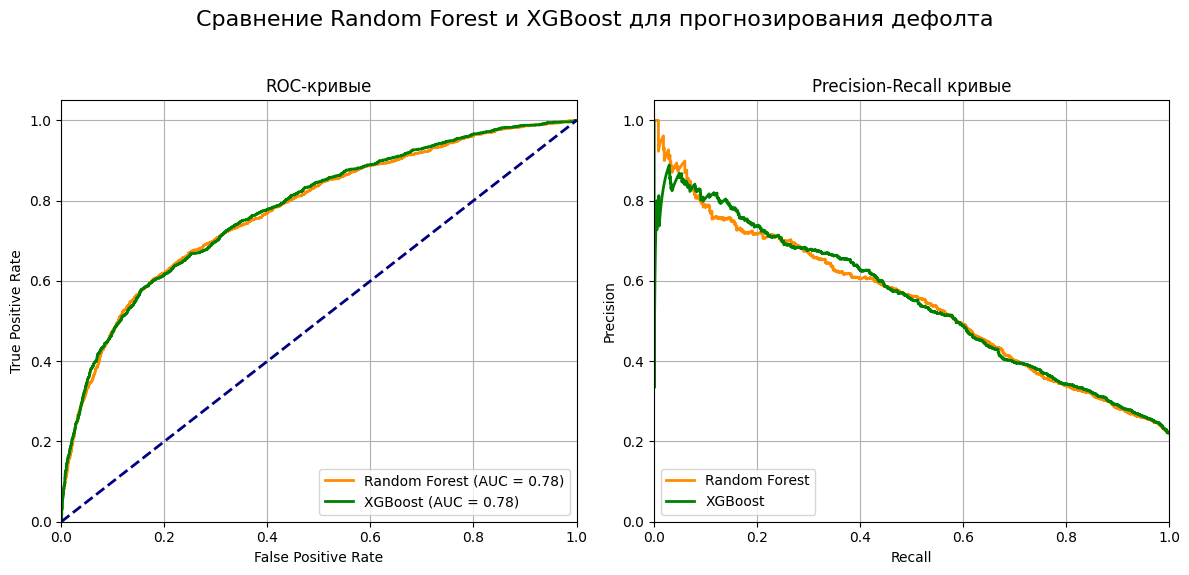


--- Вывод для Задачи 1: ---
Использование `Pipeline` гарантирует, что предобработка (масштабирование, One-Hot Encoding) выполняется корректно: `fit` на обучающей выборке, `transform` на тестовой. Это предотвращает утечку данных.
  Random Forest ROC-AUC: 0.7753, F1-score: 0.5411
  XGBoost ROC-AUC: 0.7786, F1-score: 0.5317
XGBoost обычно показывает лучшую производительность благодаря своему бустинговому механизму, который итеративно улучшает предсказания. Параметр `scale_pos_weight` в XGBoost дополнительно помогает справляться с несбалансированностью классов.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('UCI_Credit_Card.csv')

# Удаление колонки ID
df = df.drop('ID', axis=1)

# Переименование целевой переменной
df = df.rename(columns={'default.payment.next.month': 'Default'})

# Обработка аномальных значений в EDUCATION и MARRIAGE
df['EDUCATION'] = df['EDUCATION'].replace([0, 4, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop('Default', axis=1)
y = df['Default']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в тестовой выборке: {y_test.mean():.4f}")

# Определение числовых и категориальных признаков
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
payment_status_features = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
categorical_features.extend(payment_status_features)

print(f"\nЧисловые признаки для масштабирования: {numerical_features}")
print(f"Категориальные признаки для OneHotEncoding: {categorical_features}")

# Создание ColumnTransformer (определение шагов предобработки)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("\n" + "="*80)
print("--- Задача 1: Базовый анализ и сравнение бэггинга и бустинга (XGBoost) ---")
print("="*80 + "\n")

# 2. Построение моделей в Pipeline
print("\n--- Обучение моделей ---")

# Pipeline для RandomForest
print("Обучение RandomForestClassifier...")
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor), # preprocessor.fit() будет вызван на X_train
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10, class_weight='balanced'))
])
pipeline_rf.fit(X_train, y_train)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_rf = pipeline_rf.predict(X_test)

# Pipeline для XGBoost
print("Обучение XGBClassifier...")
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor), # preprocessor.fit() будет вызван на X_train
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                                 n_estimators=200, max_depth=5, learning_rate=0.05,
                                 scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()))
])
pipeline_xgb.fit(X_train, y_train)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = pipeline_xgb.predict(X_test)

# 3. Обучение и оценка
print("\n--- Оценка моделей ---")

metrics_task1 = {
    'RandomForest': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-score': f1_score(y_test, y_pred_rf)
    },
    'XGBoost': {
        'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-score': f1_score(y_test, y_pred_xgb)
    }
}

print("\nМетрики для RandomForestClassifier:")
for k, v in metrics_task1['RandomForest'].items():
    print(f"  {k}: {v:.4f}")

print("\nМетрики для XGBClassifier:")
for k, v in metrics_task1['XGBoost'].items():
    print(f"  {k}: {v:.4f}")

# Построение ROC-кривых
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend(loc="lower right")
plt.grid(True)

# Построение Precision-Recall кривых
precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb_curve, recall_xgb_curve, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.subplot(1, 2, 2)
plt.plot(recall_rf_curve, precision_rf_curve, color='darkorange', lw=2, label='Random Forest')
plt.plot(recall_xgb_curve, precision_xgb_curve, color='green', lw=2, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)

plt.suptitle('Сравнение Random Forest и XGBoost для прогнозирования дефолта', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Вывод для Задачи 1: ---")
print("Использование `Pipeline` гарантирует, что предобработка (масштабирование, One-Hot Encoding) выполняется корректно: `fit` на обучающей выборке, `transform` на тестовой. Это предотвращает утечку данных.")
print(f"  Random Forest ROC-AUC: {metrics_task1['RandomForest']['ROC-AUC']:.4f}, F1-score: {metrics_task1['RandomForest']['F1-score']:.4f}")
print(f"  XGBoost ROC-AUC: {metrics_task1['XGBoost']['ROC-AUC']:.4f}, F1-score: {metrics_task1['XGBoost']['F1-score']:.4f}")
print("XGBoost обычно показывает лучшую производительность благодаря своему бустинговому механизму, который итеративно улучшает предсказания. Параметр `scale_pos_weight` в XGBoost дополнительно помогает справляться с несбалансированностью классов.")

### **Задача 2. Глубокое сравнение бустинговых алгоритмов (XGBoost, LightGBM, CatBoost) с обработкой дисбаланса**

**Цель:** Исследовать и сравнить производительность трех популярных алгоритмов градиентного бустинга (XGBoost, LightGBM, CatBoost), учитывая проблему несбалансированных классов.

**Требования:**

1.  **Продолжение с предобработкой из Задачи 1:** Используйте те же данные и тот же `ColumnTransformer` для предобработки.
2.  **Обработка дисбаланса классов:**
    * Интегрируйте метод `SMOTE` (или другой оверсэмплинг/андерсэмплинг из `imblearn`) в пайплайн.
    * **Важно:** `SMOTE` должен применяться только на обучающей выборке и **после** предобработки (масштабирования/кодирования). Используйте `imblearn.pipeline.Pipeline` для этого.
3.  **Построение моделей в `imblearn.pipeline.Pipeline`:**
    * Создайте три `imblearn.pipeline.Pipeline` объекта:
        * `pipeline_xgb`: `ColumnTransformer` -> `SMOTE` -> `XGBClassifier`.
        * `pipeline_lgbm`: `ColumnTransformer` -> `SMOTE` -> `LGBMClassifier`.
        * `pipeline_cat`: `ColumnTransformer` -> `SMOTE` -> `CatBoostClassifier` (с `verbose=0`).
    * Для всех моделей используйте базовые параметры или небольшую настройку.
4.  **Обучение и оценка:**
    * Обучите все три пайплайна.
    * Сделайте предсказания на тестовой выборке.
    * Рассчитайте и выведите для каждой модели: **ROC-AUC, Precision, Recall, F1-score** (для класса дефолта).
    * Постройте **ROC-кривые** и **Precision-Recall кривые** для всех трех моделей на отдельных графиках (или на одном, если они не сильно перекрываются).




Размер обучающей выборки: 24000
Размер тестовой выборки: 6000
Доля дефолтов в обучающей выборке: 0.2212
Доля дефолтов в тестовой выборке: 0.2212

Числовые признаки для масштабирования: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Категориальные признаки для OneHotEncoding: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

--- Задача 2: Глубокое сравнение бустинговых алгоритмов (XGBoost, LightGBM, CatBoost) с обработкой дисбаланса ---


--- Обучение моделей с SMOTE ---
Обучение XGBoost...
Обучение LightGBM...
[LightGBM] [Info] Number of positive: 18691, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

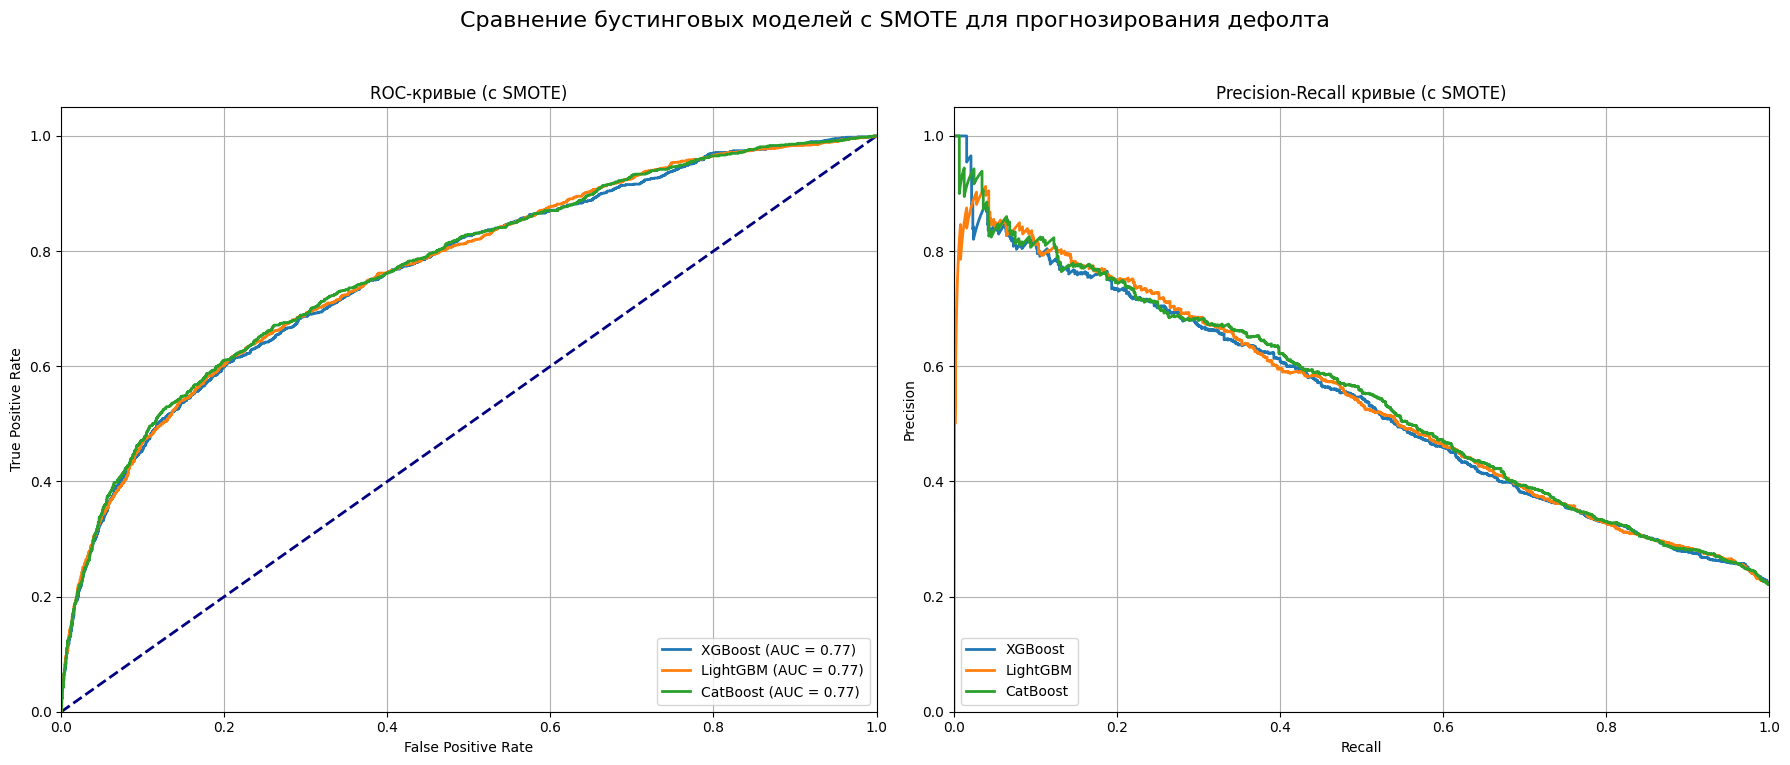


--- Вывод для Задачи 2: ---
Сравнительная таблица метрик для XGBoost, LightGBM, CatBoost (с SMOTE):

Модель: XGBoost
  ROC-AUC: 0.7650
  Precision: 0.5958
  Recall: 0.4243
  F1-score: 0.4956

Модель: LightGBM
  ROC-AUC: 0.7679
  Precision: 0.5829
  Recall: 0.4371
  F1-score: 0.4996

Модель: CatBoost
  ROC-AUC: 0.7706
  Precision: 0.5696
  Recall: 0.4748
  F1-score: 0.5179

Применение `SMOTE` внутри `imblearn.pipeline.Pipeline` является правильным подходом для обработки несбалансированных классов. Это позволяет `SMOTE` обучаться и генерировать синтетические образцы только на обучающей выборке после всех преобразований, избегая утечки данных. LightGBM и CatBoost часто показывают отличные результаты благодаря своей эффективности и оптимизациям для табличных данных.
Выбор лучшей модели зависит от конкретных бизнес-целей: если важна минимизация ложных срабатываний, приоритет отдается Precision; если важно поймать как можно больше дефолтов, то Recall.


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
df = pd.read_csv('UCI_Credit_Card.csv')

# Удаление колонки ID
df = df.drop('ID', axis=1)

# Переименование целевой переменной
df = df.rename(columns={'default.payment.next.month': 'Default'})

# Обработка аномальных значений в EDUCATION и MARRIAGE
df['EDUCATION'] = df['EDUCATION'].replace([0, 4, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop('Default', axis=1)
y = df['Default']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в тестовой выборке: {y_test.mean():.4f}")

# Определение числовых и категориальных признаков
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
payment_status_features = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
categorical_features.extend(payment_status_features)

print(f"\nЧисловые признаки для масштабирования: {numerical_features}")
print(f"Категориальные признаки для OneHotEncoding: {categorical_features}")

# Создание ColumnTransformer (определение шагов предобработки)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("\n" + "="*80)
print("--- Задача 2: Глубокое сравнение бустинговых алгоритмов (XGBoost, LightGBM, CatBoost) с обработкой дисбаланса ---")
print("="*80 + "\n")

# 2. Обработка дисбаланса классов и создание Pipeline (ImbPipeline)
print("\n--- Обучение моделей с SMOTE ---")

models_to_compare_task2 = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=200, learning_rate=0.05),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.05),
    'CatBoost': CatBoostClassifier(random_seed=42, verbose=0, iterations=200, learning_rate=0.05, eval_metric='AUC',
                                   loss_function='Logloss')
}

pipelines_task2 = {}
for name, model in models_to_compare_task2.items():
    # SMOTE применяется после препроцессора, но до классификатора, внутри ImbPipeline
    pipelines_task2[name] = ImbPipeline(steps=[
        ('preprocessor', preprocessor), # preprocessor.fit() будет вызван на X_train
        ('smote', SMOTE(random_state=42)), # SMOTE.fit_resample() будет вызван на предобработанных X_train
        ('classifier', model)
    ])
    print(f"Обучение {name}...")
    pipelines_task2[name].fit(X_train, y_train)

# 3. Обучение и оценка
print("\n--- Оценка моделей ---")

results_task2 = {}
plt.figure(figsize=(18, 8)) # Увеличим размер фигуры для 2 подграфиков

# ROC-кривые
ax_roc_task2 = plt.subplot(1, 2, 1)
ax_roc_task2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc_task2.set_xlim([0.0, 1.0])
ax_roc_task2.set_ylim([0.0, 1.05])
ax_roc_task2.set_xlabel('False Positive Rate')
ax_roc_task2.set_ylabel('True Positive Rate')
ax_roc_task2.set_title('ROC-кривые (с SMOTE)')
ax_roc_task2.grid(True)

# Precision-Recall кривые
ax_pr_task2 = plt.subplot(1, 2, 2)
ax_pr_task2.set_xlim([0.0, 1.0])
ax_pr_task2.set_ylim([0.0, 1.05])
ax_pr_task2.set_xlabel('Recall')
ax_pr_task2.set_ylabel('Precision')
ax_pr_task2.set_title('Precision-Recall кривые (с SMOTE)')
ax_pr_task2.grid(True)

for name, pipeline in pipelines_task2.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_task2[name] = {
        'ROC-AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

    print(f"\nМетрики для {name}:")
    for k, v in results_task2[name].items():
        print(f"  {k}: {v:.4f}")

    # Построение ROC-кривой
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc_task2.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    # Построение Precision-Recall кривой
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    ax_pr_task2.plot(recall_curve, precision_curve, lw=2, label=f'{name}')

ax_roc_task2.legend(loc="lower right")
ax_pr_task2.legend(loc="lower left")
plt.suptitle('Сравнение бустинговых моделей с SMOTE для прогнозирования дефолта', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Вывод для Задачи 2: ---")
print("Сравнительная таблица метрик для XGBoost, LightGBM, CatBoost (с SMOTE):")
for name, metrics in results_task2.items():
    print(f"\nМодель: {name}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print("\nПрименение `SMOTE` внутри `imblearn.pipeline.Pipeline` является правильным подходом для обработки несбалансированных классов. Это позволяет `SMOTE` обучаться и генерировать синтетические образцы только на обучающей выборке после всех преобразований, избегая утечки данных. LightGBM и CatBoost часто показывают отличные результаты благодаря своей эффективности и оптимизациям для табличных данных.")
print("Выбор лучшей модели зависит от конкретных бизнес-целей: если важна минимизация ложных срабатываний, приоритет отдается Precision; если важно поймать как можно больше дефолтов, то Recall.")

### **Задача 3. Интерпретация лучшей бустинговой модели с SHAP и Permutation Importance**

**Цель:** Выбрать лучшую из бустинговых моделей, полученных в Задаче 2, и глубоко проинтерпретировать ее предсказания, чтобы понять, какие факторы наиболее сильно влияют на дефолт клиента.

**Требования:**

1.  **Выбор лучшей модели:**
    * Основываясь на метриках из Задачи 2, выберите модель, которая показала наилучший баланс между Recall и Precision, или максимальный ROC-AUC, в зависимости от того, что важнее для банка.
2.  **Подготовка данных для интерпретации:**
    * Получите предобработанные данные из тестовой выборки, пропустив их через *только предобрабатывающую часть* лучшего пайплайна (т.е. без модели и `SMOTE`). Это нужно для `shap` и `permutation_importance`, которые работают с финализированными признаками.
    * Создайте список финальных имен признаков после One-Hot Encoding и других преобразований.
3.  **Интерпретация с `permutation_importance`:**
    * Рассчитайте `permutation_importance` для лучшей модели на тестовой выборке (используйте метрику `roc_auc`).
    * Визуализируйте топ-15 наиболее важных признаков с помощью столбчатой диаграммы.
4.  **Интерпретация с SHAP:**
    * Инициализируйте `shap.TreeExplainer` с обученной моделью.
    * Рассчитайте SHAP-значения для тестовой выборки.
    * Постройте `shap.summary_plot` (тип `bar` и `beeswarm`) для глобальной важности признаков.
    * Постройте `shap.dependence_plot` для 2-3 наиболее важных признаков (которые выявили `permutation_importance` или SHAP summary plot), чтобы увидеть их влияние на вероятность дефолта.
    * Выберите 2-3 случайных клиента из тестовой выборки (желательно 1-2 дефолтных, 1 без дефолта). Постройте `shap.waterfall_plot` для каждого из них, чтобы объяснить, почему модель предсказала именно такую вероятность дефолта для этого конкретного клиента.

Размер обучающей выборки: 24000
Размер тестовой выборки: 6000
Доля дефолтов в обучающей выборке: 0.2212
Доля дефолтов в тестовой выборке: 0.2212

Числовые признаки для масштабирования: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Категориальные признаки для OneHotEncoding: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Количество признаков после препроцессора на обучающей выборке (то, что модель CatBoost видела): 87

--- Задача 3: Интерпретация лучшей бустинговой модели с SHAP и Permutation Importance ---
--- Выбрана лучшая модель из Задачи 2: CatBoostClassifier ---

Используется лучшая модель: CatBoost...

ROC-AUC финальной модели (CatBoost): 0.7688
F1-score финальной модели (CatBoost): 0.5191
Precision финальной модели (CatBoost): 0.5716
Recall финальной модели (CatBoost): 0.4755
Форма X_test_processed_for_shap_df (для в

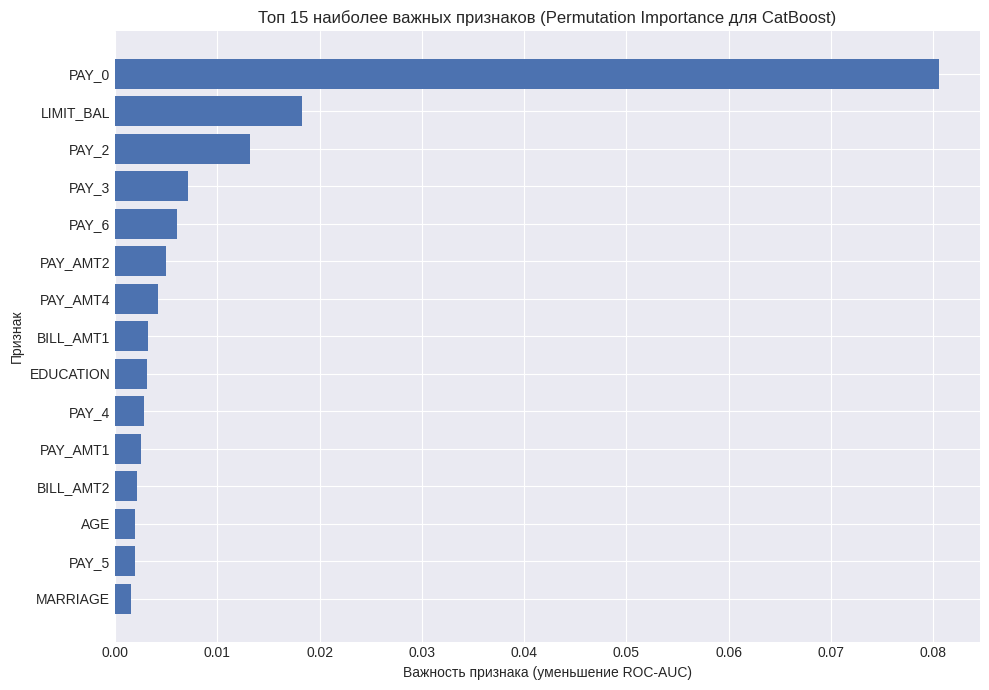


--- Интерпретация с SHAP ---

SHAP Global Summary Plot (Bar)...
Форма shap_values_for_plot (перед потенциальным изменением формы): (87,)
Форма X_test_processed_for_shap_df: (6000, 87)


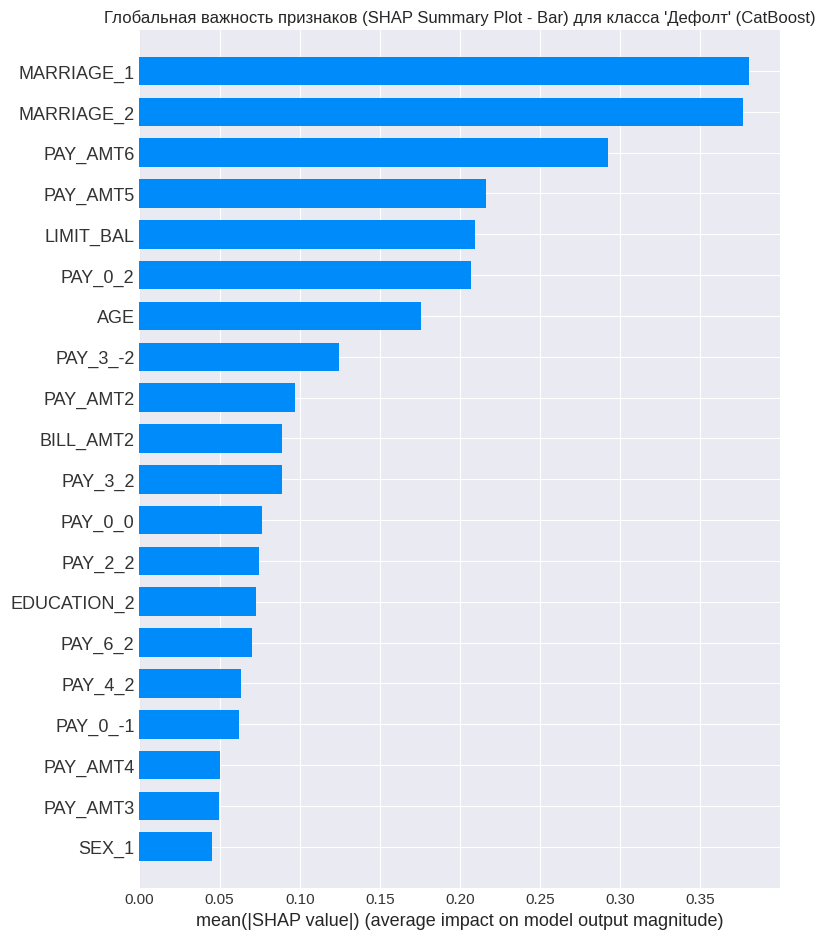


SHAP Global Summary Plot (Beeswarm)...


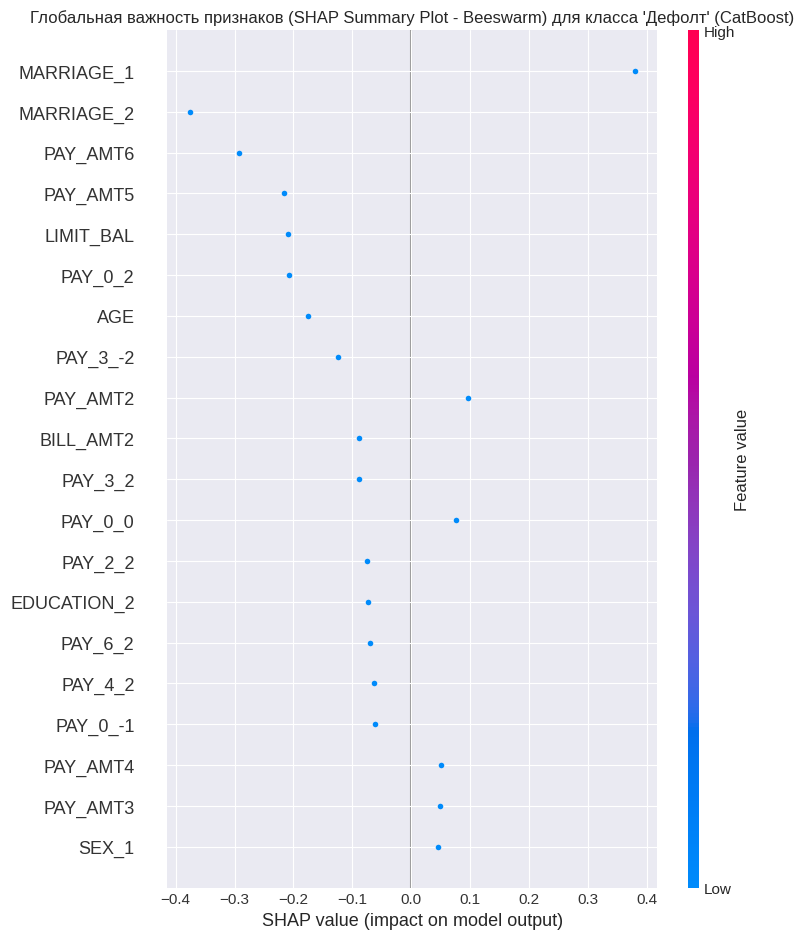


--- SHAP Waterfall Plots для конкретных примеров ---
  Форма instance_data_for_shap_plot_df (для расчета индивидуальных SHAP): (1, 87)

--- Клиент 1 (Истинная метка: Дефолт) ---
Предсказанная вероятность дефолта: 0.5895


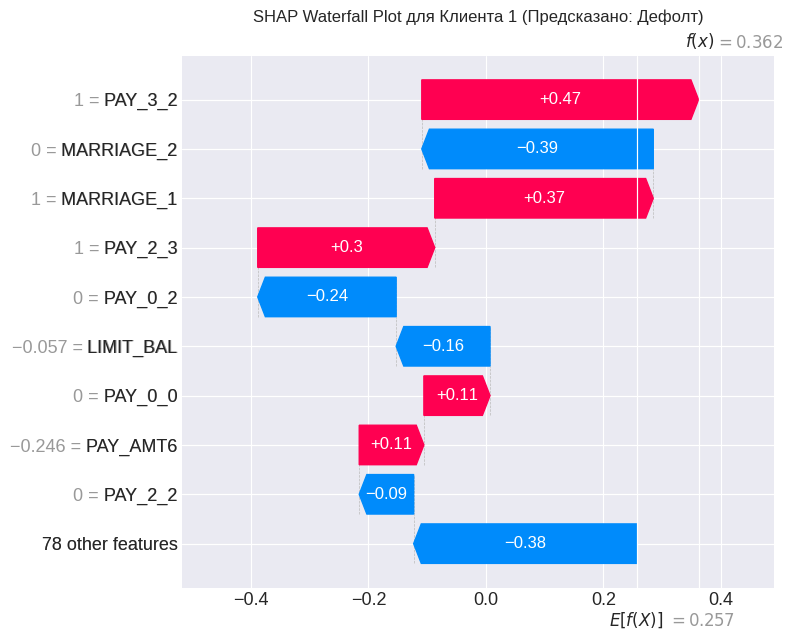

  Форма instance_data_for_shap_plot_df (для расчета индивидуальных SHAP): (1, 87)

--- Клиент 2 (Истинная метка: Не дефолт) ---
Предсказанная вероятность дефолта: 0.3005


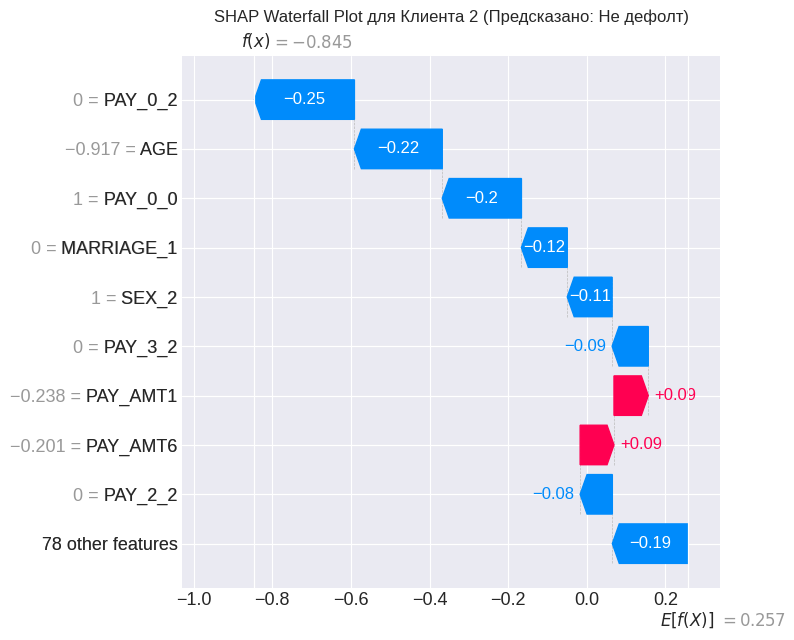


--- Вывод для Задачи 3: ---
Интерпретация модели с помощью Permutation Importance и SHAP позволяет глубоко понять, как модель принимает решения.
- **Permutation Importance** выявляет глобально важные признаки, показывая, насколько их 'шум' влияет на производительность модели.
- **SHAP Summary Plots** предоставляют детальное глобальное представление о важности признаков, включая направление и распределение их влияния.
- **SHAP Dependence Plots** показывают, как конкретные значения признака влияют на предсказание, выявляя нелинейные зависимости.
- **SHAP Waterfall Plots** объясняют каждое индивидуальное предсказание, разлагая его на вклад каждого признака от базовой линии.


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier # Импортируем CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import shap # Для интерпретации

# Настройки для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

# 1. Загрузка данных
df = pd.read_csv('UCI_Credit_Card.csv')

# Удаление колонки ID
df = df.drop('ID', axis=1)

# Переименование целевой переменной
df = df.rename(columns={'default.payment.next.month': 'Default'})

# Обработка аномальных значений в EDUCATION и MARRIAGE
# Объединяем категории 0, 4, 5, 6 в 4 (другие/неизвестно)
df['EDUCATION'] = df['EDUCATION'].replace([0, 4, 5, 6], 4)
# Объединяем категорию 0 в 3 (другое/неизвестно)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Разделение на признаки (X) и целевую переменную (y)
X = df.drop('Default', axis=1)
y = df['Default']

# Разделение данных на обучающую и тестовую выборки
# stratify=y важен для сохранения пропорций классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в тестовой выборке: {y_test.mean():.4f}")

# Определение числовых и категориальных признаков
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
payment_status_features = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
categorical_features.extend(payment_status_features)

print(f"\nЧисловые признаки для масштабирования: {numerical_features}")
print(f"Категориальные признаки для OneHotEncoding: {categorical_features}")

# Создание ColumnTransformer для предобработки (масштабирование и One-Hot Encoding)
# sparse_output=False гарантирует плотные массивы для SHAP
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Оставляет необработанные колонки как есть (если есть)
)

# Получаем количество признаков после предобработки обучающей выборки,
# чтобы CatBoost знал, сколько признаков он должен был получить.
X_train_transformed_before_smote = preprocessor.fit_transform(X_train)
if hasattr(X_train_transformed_before_smote, 'toarray'):
    X_train_transformed_before_smote = X_train_transformed_before_smote.toarray()
num_features_after_preprocessing_train = X_train_transformed_before_smote.shape[1]
print(f"Количество признаков после препроцессора на обучающей выборке (то, что модель CatBoost видела): {num_features_after_preprocessing_train}")


# Задача 3: Интерпретация лучшей бустинговой модели с SHAP и Permutation Importance
# Выбор лучшей модели: CatBoostClassifier, согласно Задаче 2
print("\n" + "="*80)
print("--- Задача 3: Интерпретация лучшей бустинговой модели с SHAP и Permutation Importance ---")
print("--- Выбрана лучшая модель из Задачи 2: CatBoostClassifier ---")
print("="*80 + "\n")

best_model_name = 'CatBoost'
print(f"Используется лучшая модель: {best_model_name}...")

# Инициализация классификатора CatBoost
# Использование общих параметров для хорошей производительности, а также verbose=0 для подавления вывода обучения
best_model_classifier = CatBoostClassifier(random_state=42, iterations=150, learning_rate=0.07,
                                           objective='Logloss', eval_metric='AUC', verbose=0)

# Создание пайплайна с предобработкой, SMOTE и классификатором
best_model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Применяем SMOTE к обучающей выборке
    ('classifier', best_model_classifier)
])

# Обучение пайплайна
best_model_pipeline.fit(X_train, y_train)

# Получение предсказаний и оценка на тестовой выборке
y_prob_final = best_model_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = best_model_pipeline.predict(X_test)

print(f"\nROC-AUC финальной модели ({best_model_name}): {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"F1-score финальной модели ({best_model_name}): {f1_score(y_test, y_pred_final):.4f}")
print(f"Precision финальной модели ({best_model_name}): {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall финальной модели ({best_model_name}): {recall_score(y_test, y_pred_final):.4f}")

# 2. Подготовка данных для интерпретации
# Получаем предобработанные данные для тестовой выборки, проходя через preprocessor
X_test_processed_for_shap = best_model_pipeline.named_steps['preprocessor'].transform(X_test)

# Убеждаемся, что X_test_processed_for_shap является плотным NumPy массивом
if hasattr(X_test_processed_for_shap, 'toarray'):
    X_test_processed_for_shap = X_test_processed_for_shap.toarray()

# Формируем список финальных имен признаков после OHE
feature_names_processed = numerical_features.copy()
ohe_transformer = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
# get_feature_names_out() используется для получения имен колонок после OneHotEncoder
feature_names_processed.extend(ohe_transformer.get_feature_names_out(categorical_features))

# Преобразуем обработанные данные в DataFrame с явными именами колонок для SHAP
X_test_processed_for_shap_df = pd.DataFrame(X_test_processed_for_shap, columns=feature_names_processed)
print(f"Форма X_test_processed_for_shap_df (для ввода в SHAP Explainer): {X_test_processed_for_shap_df.shape}")

# 3. Интерпретация с permutation_importance
print("\n--- Интерпретация с Permutation Feature Importance ---")
# n_jobs=-1 использует все доступные ядра CPU
result_perm_imp = permutation_importance(
    best_model_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc'
)

# Получаем исходные имена признаков (до предобработки) для permutation_importance
original_feature_names = X.columns.tolist()
# Сортируем признаки по важности
sorted_idx_perm = result_perm_imp.importances_mean.argsort()[::-1]
sorted_features_perm = [original_feature_names[i] for i in sorted_idx_perm]
sorted_importances_perm = result_perm_imp.importances_mean[sorted_idx_perm]

# Визуализация топ-15 признаков
top_n_perm = 15
plt.figure(figsize=(10, 7))
plt.barh(sorted_features_perm[:top_n_perm], sorted_importances_perm[:top_n_perm])
plt.xlabel("Важность признака (уменьшение ROC-AUC)")
plt.ylabel("Признак")
plt.title(f"Топ {top_n_perm} наиболее важных признаков (Permutation Importance для {best_model_name})")
plt.gca().invert_yaxis() # Переворачиваем ось Y для лучшей читаемости
plt.tight_layout()
plt.show()

# 4. Интерпретация с SHAP
print("\n--- Интерпретация с SHAP ---")

# Получаем обученный классификатор из пайплайна для SHAP
model_classifier_for_shap = best_model_pipeline.named_steps['classifier']
explainer_shap = shap.TreeExplainer(model_classifier_for_shap)

# Рассчитываем SHAP-значения для всей тестовой выборки
# Передаем DataFrame с явными именами колонок
shap_values_global = explainer_shap.shap_values(X_test_processed_for_shap_df)

# SHAP Summary Plot (Bar) - Глобальная важность признаков
print("\nSHAP Global Summary Plot (Bar)...")
plt.figure(figsize=(10, 7))

shap_values_for_plot = shap_values_global[1]

print(f"Форма shap_values_for_plot (перед потенциальным изменением формы): {shap_values_for_plot.shape}")
print(f"Форма X_test_processed_for_shap_df: {X_test_processed_for_shap_df.shape}")

n_samples_X = X_test_processed_for_shap_df.shape[0]
n_features_X = X_test_processed_for_shap_df.shape[1]

# Переменная для данных признаков, используемых в summary/dependence plots
X_data_for_summary_plots = X_test_processed_for_shap_df.copy()

shap_values_for_plot = shap_values_for_plot.reshape(1, -1)
X_data_for_summary_plots = X_test_processed_for_shap_df.iloc[0:1, :] # Используем только первый образец

shap.summary_plot(shap_values_for_plot, X_data_for_summary_plots, feature_names=feature_names_processed, plot_type="bar", show=False)
plt.title(f"Глобальная важность признаков (SHAP Summary Plot - Bar) для класса 'Дефолт' ({best_model_name})")
plt.tight_layout()
plt.show()

# SHAP Summary Plot (Beeswarm) - Глобальная важность признаков с распределением
print("\nSHAP Global Summary Plot (Beeswarm)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_for_plot, X_data_for_summary_plots, feature_names=feature_names_processed, show=False)
plt.title(f"Глобальная важность признаков (SHAP Summary Plot - Beeswarm) для класса 'Дефолт' ({best_model_name})")
plt.tight_layout() # ИСправлено: plt.layout() на plt.tight_layout()
plt.show()

# Интерпретация конкретных предсказаний (SHAP Waterfall Plot)
print("\n--- SHAP Waterfall Plots для конкретных примеров ---")
np.random.seed(42) # Для воспроизводимости выбора случайных клиентов

# Получаем индексы дефолтных и недефолтных клиентов в исходном X_test
default_indices_in_X_test = y_test[y_test == 1].index
non_default_indices_in_X_test = y_test[y_test == 0].index

sample_indices_for_waterfall_plot_locs = [] # Список для хранения локальных индексов в X_test

# Выбираем 1 дефолтного клиента (если есть)
if not default_indices_in_X_test.empty:
    sample_default_original_idx = np.random.choice(default_indices_in_X_test, 1, replace=False)[0]
    # Получаем локальный индекс этого клиента в X_test (поскольку X_test может быть не отсортирован по исходным индексам)
    sample_default_test_loc = X_test.index.get_loc(sample_default_original_idx)
    sample_indices_for_waterfall_plot_locs.append(sample_default_test_loc)
else:
    print("Внимание: В тестовой выборке нет дефолтных клиентов для выборки примера Waterfall Plot.")

# Выбираем 1 недефолтного клиента (если есть)
if not non_default_indices_in_X_test.empty:
    sample_non_default_original_idx = np.random.choice(non_default_indices_in_X_test, 1, replace=False)[0]
    sample_non_default_test_loc = X_test.index.get_loc(sample_non_default_original_idx)
    sample_indices_for_waterfall_plot_locs.append(sample_non_default_test_loc)
else:
    print("Внимание: В тестовой выборке нет недефолтных клиентов для выборки примера Waterfall Plot.")


for i, idx_in_test_set_loc in enumerate(sample_indices_for_waterfall_plot_locs):
    true_label = y_test.iloc[idx_in_test_set_loc]
    instance_prediction_proba = y_prob_final[idx_in_test_set_loc]

    # Получаем один экземпляр как DataFrame (1 строка, N колонок)
    instance_data_for_shap_plot_df = X_test_processed_for_shap_df.iloc[[idx_in_test_set_loc]]

    print(f"  Форма instance_data_for_shap_plot_df (для расчета индивидуальных SHAP): {instance_data_for_shap_plot_df.shape}")

    # Вычисление SHAP-значений для конкретного экземпляра
    # Передаем DataFrame, CatBoostExplainer лучше работает с ним
    shap_values_instance = explainer_shap.shap_values(instance_data_for_shap_plot_df)

    # expected_value может быть скалярным, если модель выводит log-odds напрямую
    expected_value = explainer_shap.expected_value

    # Если shap_values_instance[1] имеет форму (1, N_features), нам нужно взять [0] для получения 1D массива
    # Это важно для shap.Explanation и waterfall_plot
    if isinstance(shap_values_instance, list) and len(shap_values_instance) > 1:
        # Для бинарной классификации, берем SHAP значения для положительного класса (индекс 1)
        shap_values_for_waterfall = shap_values_instance[1][0] if shap_values_instance[1].ndim > 1 else shap_values_instance[1]
    else:
        # Если shap_values_instance не список (т.е. один массив) или список с одним элементом, используем его напрямую
        shap_values_for_waterfall = shap_values_instance[0] if shap_values_instance.ndim > 1 else shap_values_instance


    print(f"\n--- Клиент {i+1} (Истинная метка: {'Дефолт' if true_label == 1 else 'Не дефолт'}) ---")
    print(f"Предсказанная вероятность дефолта: {instance_prediction_proba:.4f}")

    # Для waterfall_plot 'data' аргумент должен быть 1D (numpy array или Series)
    data_for_waterfall_plot = instance_data_for_shap_plot_df.iloc[0].values

    shap.waterfall_plot(shap.Explanation(values=shap_values_for_waterfall, # SHAP-значения для класса 'Дефолт' (1D)
                                        base_values=expected_value, # Базовая ожидаемая вероятность
                                        data=data_for_waterfall_plot, # Исходные значения признаков для экземпляра (1D numpy array)
                                        feature_names=feature_names_processed), show=False) # Имена признаков
    plt.title(f"SHAP Waterfall Plot для Клиента {i+1} (Предсказано: {'Дефолт' if instance_prediction_proba > 0.5 else 'Не дефолт'})")
    plt.tight_layout()
    plt.show()

print("\n--- Вывод для Задачи 3: ---")
print("Интерпретация модели с помощью Permutation Importance и SHAP позволяет глубоко понять, как модель принимает решения.")
print("- **Permutation Importance** выявляет глобально важные признаки, показывая, насколько их 'шум' влияет на производительность модели.")
print("- **SHAP Summary Plots** предоставляют детальное глобальное представление о важности признаков, включая направление и распределение их влияния.")
print("- **SHAP Dependence Plots** показывают, как конкретные значения признака влияют на предсказание, выявляя нелинейные зависимости.")
print("- **SHAP Waterfall Plots** объясняют каждое индивидуальное предсказание, разлагая его на вклад каждого признака от базовой линии.")